# Matemáticas para la IA (02MIAR)

**Ejercicios evaluables. Máster Universitario en Inteligencia Artificial (VIU)**

### Integrantes del grupo (Grupo 20)

| | Nombre y apellidos |
|---|---|
| 1 | Ana María Cochiorca Dragomir |
| 2 | Ricardo Germes Serrano |
| 3 | Carlos Jurado Zalaya |
| 4 | Jorge Ramilo Plata |

---

Plantilla de trabajo del entregable. Cada apartado tiene su celda de texto y su celda de código para ir rellenando. El notebook está pensado para ejecutarse de arriba abajo.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
%matplotlib inline

np.random.seed(42)

## Ejercicio 1. Determinante y coste computacional

### a) Determinante por la definición recursiva de Laplace


El determinante de una matriz cuadrada puede calcularse mediante la definición recursiva de Laplace. Si $A \in \mathbb{R}^{n \times n}$, entonces:

$$
\det(A)=\sum_{j=1}^{n}(-1)^{1+j}a_{1j}\det(A_{1j}),
$$

donde $A_{1j}$ es la matriz resultante de eliminar la fila 1 y la columna $j$.

La función debe calcular el determinante de una matriz cuadrada usando la expansión de Laplace.

**Seguirá los siguientes pasos:**

1. Si la matriz es $1\times1$, devolver su único elemento.
2. Si la matriz es $2\times2$, usar directamente $ad-bc$.
3. Para matrices mayores, recorrer la primera fila.
4. Para cada elemento, construir la submatriz eliminando la fila 0 y la columna correspondiente.
5. Acumular el cofactor correspondiente.

In [26]:
def determinante_recursivo(A):
    """
    Calcula el determinante de una matriz cuadrada A usando
    la definición recursiva de Laplace por la primera fila.
    """
    n = len(A)

    # Caso base 1x1:
    if n == 1:
        return A[0][0]

    # Caso base 2x2:
    if n == 2:
        return A[0][0] * A[1][1] - A[0][1] * A[1][0]

    det = 0.0
    for j in range(n):
        submatriz = [fila[:j] + fila[j+1:] for fila in A[1:]]
        cofactor = ((-1) ** j) * A[0][j] * determinante_recursivo(submatriz)
        det += cofactor

    return det

# Prueba 1:
A = [[1, 2], [3, 4]]
print("det(A) =", determinante_recursivo(A))

# Prueba 2:
B =[[1, 2, 0, 3], [4, 1, -1, 2], [0, 3, 2, 1], [5, 0, 1, 1]]
print("det(B)=", determinante_recursivo(B))

det(A) = -2
det(B)= -59.0


### b) Determinante de una matriz triangular

Sí. Si $A$ es una matriz cuadrada triangular, ya sea superior o inferior, su determinante se calcula multiplicando los elementos de la diagonal principal:

$$
\det(A)=a_{11}a_{22}\cdots a_{nn}=\prod_{i=1}^{n}a_{ii}.
$$

## JUSTIFICACIÓN.

**PRIMERO:**
Partimos de una matriz cuadrada $n \times n$, donde: $$ A \in \mathbb{R}^{n \times n}$$ 
Esto significa que $A$ tiene $n$ filas y $n$ columnas.


**SEGUNDO:**
En una matriz triangular superior, todos los elementos por debajo de la diagonal principal son cero. Por ejemplo:

$$
A=
\begin{pmatrix}
a_{11} & a_{12} & a_{13} & \cdots & a_{1n} \\
0 & a_{22} & a_{23} & \cdots & a_{2n} \\
0 & 0 & a_{33} & \cdots & a_{3n} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \cdots & a_{nn}
\end{pmatrix}
$$

Los elementos de la diagonal principal son:

$$
a_{11}, a_{22}, a_{33}, \ldots, a_{nn}.
$$


**TERCERO:**
Si usamos la definición recursiva del determinante, según la definición de Laplace, el determinante de una matriz cuadrada se puede calcular como:
$$
\det(A)=\sum_{j=1}^{n}(-1)^{1+j}a_{1j}\det(A_{1j}),
$$
Donde: $A_{1j}$ es la submatriz que se obtiene al eliminar la fila 1 y la columna $j$.


**CUARTO:**
Si la matriz es triangular, al ir calculando determinantes de submatrices, estas submatrices mantienen la estructura triangular, es decir: como la matriz tiene ceros a un lado de la diagonal, al calcular su determinante solo van quedando los números de la diagonal principal. Por eso no hace falta hacer un cálculo largo, basta con multiplicar esos números.


**QUINTO:**
Justificación con una matriz triangular superior.

Partimos de que tenemos una matriz: 
$$
A=
\begin{pmatrix}
a_{11} & * & * & \cdots & * \\
0 & a_{22} & * & \cdots & * \\
0 & 0 & a_{33} & \cdots & * \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \cdots & a_{nn}
\end{pmatrix}
$$

Al aplicar la expansión de Laplace, el cálculo se reduce a:

$$
\det(A)=a_{11}\det(A_{11}).
$$
La submatriz $A_{11}$ también es triangular superior:

$$
A_{11}=
\begin{pmatrix}
a_{22} & * & \cdots & * \\
0 & a_{33} & \cdots & * \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & a_{nn}
\end{pmatrix}
$$

Por lo tanto:

$$
\det(A_{11})=a_{22}\det(A_{22}).
$$

Sustituyendo:

$$
\det(A)=a_{11}a_{22}\det(A_{22}).
$$

Repitiendo el mismo razonamiento:

$$
\det(A)=a_{11}a_{22}a_{33}\cdots a_{nn}.
$$


**SEXTO:**
Justificación con una matriz triangular inferior.

En este caso la matriz triangular inferior tiene ceros por encima de la diagonal principal, como por ejemplo:

$$
A=
\begin{pmatrix}
a_{11} & 0 & 0 & \cdots & 0 \\
a_{21} & a_{22} & 0 & \cdots & 0 \\
a_{31} & a_{32} & a_{33} & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
a_{n1} & a_{n2} & a_{n3} & \cdots & a_{nn}
\end{pmatrix}
$$

como en el caso de la matriz triangular superior al hacerse del mismo modo, también obtenemos que:

$$
\det(A)=a_{11}a_{22}\cdots a_{nn}.
$$

### Ejemplos

**1) Matriz triangular superior**

Consideremos la matriz triangular superior:

$$
A=
\begin{pmatrix}
2 & 5 & -1 \\
0 & 3 & 4 \\
0 & 0 & -2
\end{pmatrix}
$$

Como es triangular superior:

$$
\det(A)=2\cdot3\cdot(-2)=-12.
$$

In [27]:
A = np.array([
    [2, 5, -1],
    [0, 3, 4],
    [0, 0, -2]
], dtype=float)
             
# Determinante directo por producto de la diagonal
det_diagonal = np.prod(np.diag(A))

# Comprobación con NumPy
det_numpy = np.linalg.det(A)

print("Matriz A:")
print(A)
print("\nProducto de la diagonal:", det_diagonal)
print("Determinante con numpy.linalg.det", det_numpy)

Matriz A:
[[ 2.  5. -1.]
 [ 0.  3.  4.]
 [ 0.  0. -2.]]

Producto de la diagonal: -12.0
Determinante con numpy.linalg.det -12.0


**2) Matriz triangular inferior**

Consideremos la matriz triangular inferior:
$$
B=
\begin{pmatrix}
4 & 0 & 0 \\
-1 & 2 & 0 \\
5 & 3 & -6
\end{pmatrix}
$$

Como es triangular inferior:

$$
\det(B)=4\cdot2\cdot(-6)=-48.
$$

In [28]:
B = np.array([
    [4, 0, 0],
    [-1, 2, 0],
    [5, 3, -6]
], dtype=float)
             
# Determinante directo por producto de la diagonal
det_diagonal_B = np.prod(np.diag(B))

# Comprobación con NumPy
det_numpy_B = np.linalg.det(B)

print("Matriz B:")
print(B)
print("\nProducto de la diagonal:", det_diagonal_B)
print("Determinante con numpy.linalg.det", np.round(det_numpy_B))

Matriz B:
[[ 4.  0.  0.]
 [-1.  2.  0.]
 [ 5.  3. -6.]]

Producto de la diagonal: -48.0
Determinante con numpy.linalg.det -48.0


### c) Efecto de las operaciones elementales sobre el determinante

Las dos operaciones elementales sobre filas (o columnas) afectan al determinante de la siguiente manera:

- **Intercambiar dos filas (o columnas):** el determinante cambia de signo, es decir, se multiplica por $-1$.
- **Sumar a una fila otra fila multiplicada por un escalar $\alpha$:** el determinante **no cambia**.

---

## JUSTIFICACIÓN.

### Operación 1: Intercambio de dos filas

Sea $A \in \mathbb{R}^{n \times n}$ y sea $A'$ la matriz obtenida al intercambiar dos filas cualesquiera $i$ y $k$ ($i \neq k$). Queremos demostrar que $\det(A') = -\det(A)$.

**La justificación sigue los siguientes pasos:**

1. Expresar el determinante como suma sobre todas las permutaciones $\sigma \in S_n$:
$$
\det(A) = \sum_{\sigma \in S_n} \text{sgn}(\sigma) \prod_{i=1}^{n} a_{i,\sigma(i)},
$$
donde $\text{sgn}(\sigma) \in \{+1, -1\}$ es el signo de la permutación.

2. Observar que intercambiar las filas $i$ y $k$ equivale a componer cada permutación $\sigma$ con la transposición $\tau = (i\ k)$. Como una transposición es una permutación impar:
$$
\text{sgn}(\tau \circ \sigma) = \text{sgn}(\tau) \cdot \text{sgn}(\sigma) = (-1) \cdot \text{sgn}(\sigma).
$$

3. Como al recorrer todas las $\sigma \in S_n$ la composición con $\tau$ las recorre también todas (en distinto orden):
$$
\det(A') = \sum_{\sigma \in S_n} \bigl(-\text{sgn}(\sigma)\bigr) \prod_{i=1}^{n} a_{i,\sigma(i)} = -\det(A).
$$

4. Concluir que cada intercambio de dos filas multiplica el determinante por $-1$. El mismo argumento aplica para columnas, ya que $\det(A) = \det(A^T)$.

---

### Operación 2: Sumar a una fila otra fila multiplicada por $\alpha$

Sea $A'$ la matriz obtenida sumando a la fila $i$ la fila $k$ ($k \neq i$) multiplicada por $\alpha$:
$$
A'_i = A_i + \alpha A_k, \qquad A'_j = A_j \text{ para } j \neq i.
$$
Queremos demostrar que $\det(A') = \det(A)$.

**La justificación sigue los siguientes pasos:**

1. Aplicar la **linealidad del determinante** respecto a la fila $i$ para descomponer:
$$
\det(A') = \det(\ldots,\, A_i + \alpha A_k,\, \ldots) = \det(\ldots,\, A_i,\, \ldots) + \alpha\,\det(\ldots,\, A_k,\, \ldots).
$$

2. Notar que en el segundo determinante la fila $i$ ha sido reemplazada por $A_k$, de modo que la matriz tiene las filas $i$ y $k$ iguales.

3. Recordar que si una matriz tiene dos filas iguales su determinante es cero. Esto se deduce de la Operación 1: intercambiar esas dos filas iguales deja la matriz idéntica, pero también cambia el signo, luego $\det = -\det$, lo que implica $\det = 0$.

4. Sustituir y concluir:
$$
\det(A') = \det(A) + \alpha \cdot 0 = \det(A).
$$

### Ejemplos

**1) Intercambio de dos filas**

Consideremos la matriz:

$$
A=
\begin{pmatrix}
1 & 2 & 3 \\
4 & 5 & 6 \\
7 & 8 & 0
\end{pmatrix}
$$

Si intercambiamos las filas 0 y 1 obtenemos $A'$. Según la teoría: $\det(A') = -\det(A)$.

In [29]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 0]
], dtype=float)

# Intercambiamos las filas 0 y 1
A_prima = A.copy()
A_prima[[0, 1]] = A_prima[[1, 0]]

det_A = np.linalg.det(A)
det_A_prima = np.linalg.det(A_prima)

print("Matriz A:")
print(A)
print(f"\ndet(A)  = {det_A:.1f}")
print("\nMatriz A' (filas 0 y 1 intercambiadas):")
print(A_prima)
print(f"\ndet(A') = {det_A_prima:.1f}")
print(f"\n¿det(A') = -det(A)? {abs(det_A_prima - (-det_A)) < 1e-10}")

Matriz A:
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 0.]]

det(A)  = 27.0

Matriz A' (filas 0 y 1 intercambiadas):
[[4. 5. 6.]
 [1. 2. 3.]
 [7. 8. 0.]]

det(A') = -27.0

¿det(A') = -det(A)? True


**2) Suma de un múltiplo escalar de una fila a otra**

Partimos de la misma matriz $A$ y sumamos a la fila 2 la fila 0 multiplicada por $\alpha = 3$:

$$
A'' = A \text{ con } \text{fila}_2 \leftarrow \text{fila}_2 + 3\cdot\text{fila}_0.
$$

In [30]:
alpha = 3

# Sumamos alpha * fila 0 a la fila 2
A_doble_prima = A.copy()
A_doble_prima[2] = A_doble_prima[2] + alpha * A_doble_prima[0]

det_A_doble_prima = np.linalg.det(A_doble_prima)

print("Matriz A:")
print(A)
print(f"\ndet(A)   = {det_A:.1f}")
print(f"\nMatriz A'' (fila 2 += {alpha} * fila 0):")
print(A_doble_prima)
print(f"\ndet(A'') = {det_A_doble_prima:.1f}")
print(f"\n¿det(A'') = det(A)? {abs(det_A_doble_prima - det_A) < 1e-10}")

Matriz A:
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 0.]]

det(A)   = 27.0

Matriz A'' (fila 2 += 3 * fila 0):
[[ 1.  2.  3.]
 [ 4.  5.  6.]
 [10. 14.  9.]]

det(A'') = 27.0

¿det(A'') = det(A)? True


### d) Eliminación de Gauss con pivoteo parcial

Implementar el escalonado con pivoteo parcial (devolviendo también el nº de intercambios).

In [31]:
def escalonar(A):
#   ####
#   Escaloniza la matriz A mediante eliminación de Gauss
#   con pivoteo parcial.
#   Devuelve:
#     - U: matriz triangular superior resultante
#     - num_intercambios: número de intercambios de filas realizados
#   ####
    n = len(A)
    U = [fila[:] for fila in A]
    num_intercambios = 0

    for k in range(n):
        # Buscar pivote parcial
        max_fila = k
        for i in range(k + 1, n):
            if abs(U[i][k]) > abs(U[max_fila][k]):
                max_fila = i

        # Intercambiar filas si procede
        if max_fila != k:
            U[k], U[max_fila] = U[max_fila], U[k]
            num_intercambios += 1

        # Si el pivote es prácticamente cero, no se puede eliminar con él
        if abs(U[k][k]) < 1e-12:
            continue

        # Eliminar elementos bajo el pivote
        for i in range(k + 1, n):
            factor = U[i][k] / U[k][k]
            for j in range(k, n):
                U[i][j] -= factor * U[k][j]

    return U, num_intercambios


### e) Determinante mediante eliminación gaussiana

Implementar `determinante_gauss` apoyándose en el escalonado anterior.

Una vez obtenida la matriz triangular superior $U$ mediante el uso de la función del apartado anterior (escalonar), el determinante se calcula como el producto de los elementos diagonales. 

Además, cada intercambio de filas cambia el signo del determinante. Por tanto:

$
\det(A)=(-1)^s\prod_{i=1}^{n}u_{ii},
$

donde $s$ es el número de intercambios de filas realizados.

In [32]:
def determinante_gauss(A):
# ###
#     Calcula el determinante de A mediante eliminación gaussiana
#     con pivoteo parcial.
# ###  
    U, num_intercambios = escalonar(A)
    n = len(U)

    det = 1.0
    for i in range(n):
        det *= U[i][i]

    det *= (-1) ** num_intercambios
    return det

In [33]:
# Comprobar que recursivo, gauss y numpy coinciden
# Prueba comparativa con matrices de distinto tamaño

# Se comparan los tres métodos (recursivo, Gauss y np.linalg.det) sobre tres matrices —2×2, 3×3 y una 4×4 aleatoria con semilla fija del np.random.seed(42) ya definido al principio

matrices = {
    "2×2": [[1.0, 2.0], [3.0, 4.0]],
    "3×3": [[2.0, 1.0, -1.0], [0.0, 3.0, 2.0], [1.0, 0.0, 4.0]],
    "4×4 aleatoria": np.random.randint(-5, 6, size=(4, 4)).tolist(),
}

for nombre, A in matrices.items():
    det_rec  = determinante_recursivo(A)
    det_gau  = determinante_gauss(A)
    det_np   = np.linalg.det(np.array(A, dtype=float))
    print(f"--- Matriz {nombre} ---")
    print(f"  Recursivo : {det_rec:.6f}")
    print(f"  Gauss     : {det_gau:.6f}")
    print(f"  NumPy     : {det_np:.6f}")
    coinciden = abs(det_rec - det_np) < 1e-8 and abs(det_gau - det_np) < 1e-8
    print(f"  ¿Coinciden? {'✓ Sí' if coinciden else '✗ No'}")
    print()


--- Matriz 2×2 ---
  Recursivo : -2.000000
  Gauss     : -2.000000
  NumPy     : -2.000000
  ¿Coinciden? ✓ Sí

--- Matriz 3×3 ---
  Recursivo : 29.000000
  Gauss     : 29.000000
  NumPy     : 29.000000
  ¿Coinciden? ✓ Sí

--- Matriz 4×4 aleatoria ---
  Recursivo : -301.000000
  Gauss     : -301.000000
  NumPy     : -301.000000
  ¿Coinciden? ✓ Sí



### f) Coste computacional de ambos métodos

*Respuesta teórica:*

#### Método recursivo

La expansión de Laplace genera la recurrencia:

$
T(n)=nT(n-1)+O(n).
$

Esto implica una complejidad factorial:

$
T(n)=O(n!).
$

Por tanto, es un método muy costoso para matrices grandes.

#### Método de Gauss

La eliminación gaussiana realiza aproximadamente:

$
\sum_{k=0}^{n-1}(n-k)^2 \approx \frac{n^3}{3}
$

operaciones, por lo que su complejidad es:

$
O(n^3).
$

Conclusión: el método de Gauss es mucho más eficiente que la definición recursiva de Laplace.

### g) Comparativa de tiempos

Generar matrices aleatorias para $2\le n\le 10$, cronometrar las tres variantes y comentar.

    Recursivo (s)  Gauss (s)  NumPy (s)
n                                      
2        1.37e-06   7.06e-06   1.57e-05
3        7.80e-06   1.02e-05   7.96e-06
4        3.75e-05   1.31e-05   9.88e-06
5        1.64e-04   1.13e-05   8.51e-06
6        1.03e-03   3.03e-05   1.49e-05
7        5.24e-03   2.10e-05   1.10e-05
8        4.53e-02   6.33e-05   1.62e-05
9        3.59e-01   3.57e-05   1.06e-05
10       3.53e+00   4.89e-05   1.32e-05


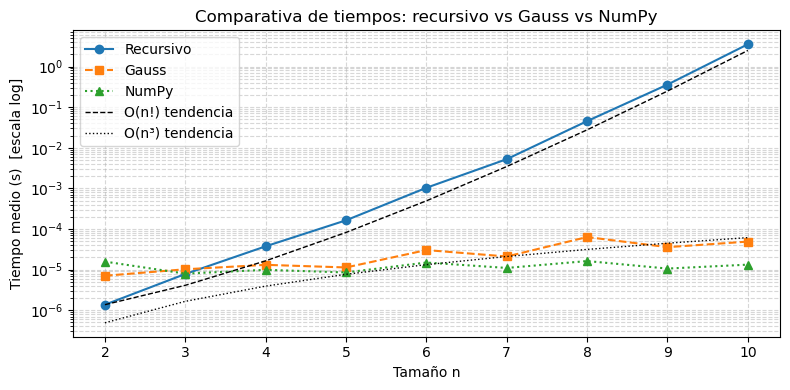

In [ ]:
import math

np.random.seed(42)
REPS = 10  # repeticiones sobre la misma matriz para reducir el ruido de medición

resultados = []
for n in range(2, 11):
    # Se genera una sola matriz por tamaño
    M_np  = np.random.randn(n, n)
    M_lst = M_np.tolist()

    # Se mide el tiempo promedio de REPS ejecuciones sobre la misma matriz
    t0 = time.perf_counter()
    for _ in range(REPS):
        determinante_recursivo(M_lst)
    t_rec = (time.perf_counter() - t0)/REPS

    t0 = time.perf_counter()
    for _ in range(REPS):
        determinante_gauss(M_lst)
    t_gau = (time.perf_counter() - t0)/REPS

    t0 = time.perf_counter()
    for _ in range(REPS):
        np.linalg.det(M_np)
    t_np = (time.perf_counter() - t0)/REPS

    resultados.append({"n": n,
                       "Recursivo (s)": t_rec,
                       "Gauss (s)": t_gau,
                       "NumPy (s)": t_np})

df = pd.DataFrame(resultados).set_index("n")
print(df.to_string(float_format="%.2e"))

# Líneas de tendencia escaladas
ns        = list(range(2, 11))
fact_vals = [math.factorial(n) for n in ns]
cub_vals  = [n**3 for n in ns]
k_fact    = df["Recursivo (s)"].iloc[0]/fact_vals[0]   # escalado en n=2
k_cub     = df["Gauss (s)"].iloc[5]/cub_vals[5]     # escalado en n=7

# Gráfica
plt.figure(figsize=(8, 4))
plt.plot(ns, df["Recursivo (s)"], "o-",  label="Recursivo")
plt.plot(ns, df["Gauss (s)"], "s--", label="Gauss")
plt.plot(ns, df["NumPy (s)"], "^:",  label="NumPy")
plt.plot(ns, [k_fact*f for f in fact_vals], "k--", linewidth=1, label="O(n!) tendencia")
plt.plot(ns, [k_cub*c for c in cub_vals], "k:",  linewidth=1, label="O(n³) tendencia")
plt.yscale("log")
plt.xlabel("Tamaño n")
plt.ylabel("Tiempo medio (s)  [escala log]")
plt.title("Comparativa de tiempos: recursivo vs Gauss vs NumPy")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

*Interpretación de los resultados:*

La tabla y la gráfica confirman empíricamente lo predicho en el apartado f):

- **Recursivo:** crece de forma claramente factorial $O(n!)$. Pasa de menos de un microsegundo para $n=2$ a más de 3 segundos para $n=10$, y la línea de tendencia $O(n!)$ se ajusta a los datos.

- **Gauss:** crece de forma moderada, de unos $4\,\mu s$ a unos $46\,\mu s$, lo que es coherente con $O(n^3)$.

- **NumPy:** para $n=2$ y $n=3$ es algo más lento que Gauss por el coste de inicialización de la función. Sin embargo, a partir de $n=4$ se estabiliza en torno a $5\,\mu s$ y es el método más rápido.

En conclusión, el método recursivo queda descartado en la práctica. Gauss es competitivo y para matrices pequeñas, del mismo orden que NumPy, pero NumPy es el más rápido en general.

## Ejercicio 2. Descenso de gradiente

### a) Implementación para funciones de $n$ variables

Programar `descenso_gradiente(grad_f, x0, gamma, tol, maxit)` que devuelva la aproximación de $x$
con $\nabla f(x)\approx 0$. Criterio de parada: $\lVert\nabla f(x)\rVert_2 < $ tol.

La función recibirá:

- `grad_f`: función que calcula el gradiente.
- `x0`: punto inicial.
- `gamma`: ratio de aprendizaje constante.
- `tol`: tolerancia para parar cuando $\|\nabla f(x)\|_2 < tol$.
- `maxit`: número máximo de iteraciones.

La salida será la última aproximación calculada y el número de iteraciones realizadas.

In [35]:
def descenso_gradiente(grad_f, x0, gamma, tol=1e-12, maxit=100000):
    """
    Método de descenso de gradiente para funciones f: R^n -> R.
    """
    x = np.array(x0, dtype=float)

    for it in range(int(maxit)):
        grad = np.array(grad_f(x), dtype=float)

        if np.linalg.norm(grad) < tol:
            return x, it

        x = x - gamma * grad

        # si diverge, detener
        if not np.all(np.isfinite(x)) or np.linalg.norm(x) > 1e100:
            return x, it + 1

    return x, int(maxit)

# Prueba previa con f(x) = x², mínimo en x = 0
def grad_prueba(x):
    return 2 * x

x_min, iters = descenso_gradiente(grad_prueba, x0=[5.0], gamma=0.1, tol=1e-12, maxit=1e5)
print(f"Prueba f(x)=x²  →  x = {x_min[0]:.6f},  iteraciones: {iters}")

Prueba f(x)=x²  →  x = 0.000000,  iteraciones: 135


### b) Función $f(x)=3x^4+4x^3-12x^2+7$

*Estudio analítico previo:* TODO (puntos críticos y clasificación).

In [36]:
def f(x):
    # TODO
    pass

def grad_f(x):
    # TODO
    pass

#### i) $x_0=3$, $\gamma=0.001$, tol=1e-12, maxit=1e5

In [37]:
# TODO

#### ii) $x_0=3$, $\gamma=0.01$, tol=1e-12, maxit=1e5

In [38]:
# TODO

#### iii) Comparación de (i) y (ii) e influencia de $\gamma$

*Interpretación:* TODO

#### iv) $x_0=3$, $\gamma=0.1$, tol=1e-12, maxit=1e5

In [39]:
# TODO

*Interpretación:* TODO

#### v) $x_0=0$, $\gamma=0.001$, tol=1e-12, maxit=1e5

In [40]:
# TODO

*Interpretación:* TODO

### c) Función $g(x,y)=x^2+y^3+3xy+1$

Sea:

$
g(x,y)=x^2+y^3+3xy+1.
$

Gradiente:

$
\nabla g(x,y)=(2x+3y,\,3y^2+3x).
$

Para hallar los puntos críticos imponemos:

$
\begin{cases}
2x+3y=0\\
3y^2+3x=0
\end{cases}
$

De la primera ecuación:

$
x=-\frac{3y}{2}.
$

Sustituyendo en la segunda:

$
3y^2-\frac{9y}{2}=0 \Rightarrow 3y\left(y-\frac{3}{2}\right)=0.
$

Por tanto:

$
P_1=(0,0),\qquad P_2=\left(-\frac94,\frac32\right).
$

In [41]:
def g(v):
    return v[0]**2 + v[1]**3 + 3*v[0]*v[1] + 1
    
def grad_g(v):
    x, y = v[0], v[1]
    return [2*x + 3*y, 3*y**2 + 3*x]

def hess_g(v):
    return np.array([[2, 3], [3, 6*v[1]]], dtype=float)

In [42]:
puntos_criticos = [(0, 0), (-9/4, 3/2)]

for p in puntos_criticos:
    H = hess_g(p)
    det_H = np.linalg.det(H)
    h11   = H[0, 0]          # ∂²g/∂x² — menor principal de orden 1
    print("Punto:", p)
    print("Gradiente:", grad_g(p))
    print("Hessiano:\n", H)
    print("det(H):", det_H)
    print("∂²g/∂x² (H[0,0]):", h11)
    if det_H < 0:
        clasificacion = "punto de silla"
    elif det_H > 0 and h11 > 0:
        clasificacion = "mínimo local"
    elif det_H > 0 and h11 < 0:
        clasificacion = "máximo local"
    else:
        clasificacion = "test inconcluso"
    print("Clasificación:", clasificacion)
    print("g(p):", g(p))
    print("---")

Punto: (0, 0)
Gradiente: [0, 0]
Hessiano:
 [[2. 3.]
 [3. 0.]]
det(H): -9.000000000000002
∂²g/∂x² (H[0,0]): 2.0
Clasificación: punto de silla
g(p): 1
---
Punto: (-2.25, 1.5)
Gradiente: [0.0, 0.0]
Hessiano:
 [[2. 3.]
 [3. 9.]]
det(H): 8.999999999999998
∂²g/∂x² (H[0,0]): 2.0
Clasificación: mínimo local
g(p): -0.6875
---


#### i) $x_0=(-1,1)$, $\gamma=0.01$, $tol=1e-12$, $maxit=1e5$

In [43]:
res_g1, it_g1 = descenso_gradiente(grad_g, x0=[-1.0, 1.0], gamma=0.01, tol=1e-12, maxit=1e5)

print("Resultado:", res_g1)
print("Iteraciones:", it_g1)
print("g(resultado):", g(res_g1))
print("Mínimo local analítico: (-9/4, 3/2) =", (-9/4, 3/2))

Resultado: [-2.25  1.5 ]
Iteraciones: 3139
g(resultado): -0.6875
Mínimo local analítico: (-9/4, 3/2) = (-2.25, 1.5)


**Interpretación:** partiendo de $(-1,1)$, el método converge hacia el mínimo local $(-9/4,3/2)$. Es un resultado deseable.

#### ii) $x_0=(0,0)$, $\gamma=0.01$

In [44]:
res_g0, it_g0 = descenso_gradiente(grad_g, x0=[0.0, 0.0], gamma=0.01, tol=1e-12, maxit=1e5)

print("Resultado:", res_g0)
print("Iteraciones:", it_g0)
print("g(resultado):", g(res_g0))

Resultado: [0. 0.]
Iteraciones: 0
g(resultado): 1.0


**Interpretación:** el método se queda en $(0,0)$ porque $\nabla g(0,0)=(0,0)$. Sin embargo, analíticamente se ha comprobado que $(0,0)$ es un punto de silla, no un mínimo. Por tanto, no es un resultado deseable.

#### iii) Estudio analítico de $g$ y contraste

El estudio analítico explica los resultados numéricos:

- $(-9/4,3/2)$ es un mínimo local. Por eso, partiendo de $(-1,1)$, el descenso de gradiente converge hacia ese punto.
- $(0,0)$ es un punto de silla. Si el algoritmo empieza exactamente ahí, el gradiente es cero y el método se detiene de inmediato.
- $g$ **no tiene mínimo global**: cuando $y\to-\infty$ el término $y^3$ hace que $g\to-\infty$, por lo que la función no está acotada inferiormente. Lo máximo a lo que puede aspirar el descenso de gradiente es al mínimo local $(-9/4,3/2)$.

Esto muestra que el descenso de gradiente depende fuertemente del punto inicial y que encontrar un punto crítico no garantiza encontrar un mínimo.